In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy
#from utils import *
import math
%matplotlib inline

In [2]:
data = np.loadtxt('ex1data1.txt', delimiter=',')

x_train = data[:, 0]
y_train = data[:, 1]

print("x_train:", x_train)
print("y_train:", y_train)

x_train: [ 6.1101  5.5277  8.5186  7.0032  5.8598  8.3829  7.4764  8.5781  6.4862
  5.0546  5.7107 14.164   5.734   8.4084  5.6407  5.3794  6.3654  5.1301
  6.4296  7.0708  6.1891 20.27    5.4901  6.3261  5.5649 18.945  12.828
 10.957  13.176  22.203   5.2524  6.5894  9.2482  5.8918  8.2111  7.9334
  8.0959  5.6063 12.836   6.3534  5.4069  6.8825 11.708   5.7737  7.8247
  7.0931  5.0702  5.8014 11.7     5.5416  7.5402  5.3077  7.4239  7.6031
  6.3328  6.3589  6.2742  5.6397  9.3102  9.4536  8.8254  5.1793 21.279
 14.908  18.959   7.2182  8.2951 10.236   5.4994 20.341  10.136   7.3345
  6.0062  7.2259  5.0269  6.5479  7.5386  5.0365 10.274   5.1077  5.7292
  5.1884  6.3557  9.7687  6.5159  8.5172  9.1802  6.002   5.5204  5.0594
  5.7077  7.6366  5.8707  5.3054  8.2934 13.394   5.4369]
y_train: [17.592    9.1302  13.662   11.854    6.8233  11.886    4.3483  12.
  6.5987   3.8166   3.2522  15.505    3.1551   7.2258   0.71618  3.5129
  5.3048   0.56077  3.6518   5.3893   3.1386  21.767    

In [3]:
print("Type of x_train: ", type(x_train))
print(x_train[:5])

Type of x_train:  <class 'numpy.ndarray'>
[6.1101 5.5277 8.5186 7.0032 5.8598]


In [4]:
print("Type of y_train: ", type(y_train))
print(x_train[:5])

Type of y_train:  <class 'numpy.ndarray'>
[6.1101 5.5277 8.5186 7.0032 5.8598]


In [5]:
# Check dimensions of dataset
print("Shape of x_train is: ", x_train.shape)
print("Shape of y_train is: ", y_train.shape)
print("Number of training examples (m): ", len(x_train))

Shape of x_train is:  (97,)
Shape of y_train is:  (97,)
Number of training examples (m):  97


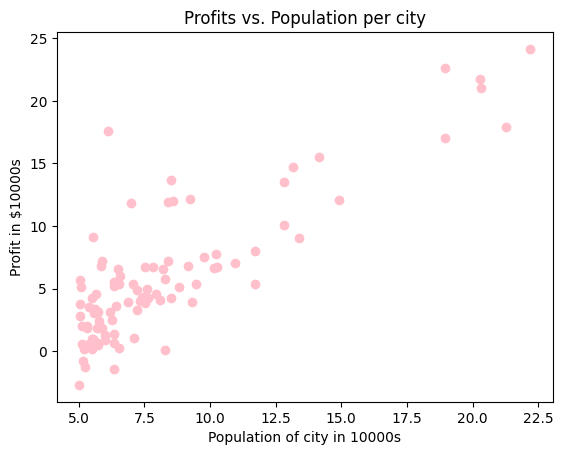

In [6]:
plt.scatter(x_train, y_train, marker='o', c='pink')
plt.title("Profits vs. Population per city")
plt.ylabel("Profit in $10000s")
plt.xlabel("Population of city in 10000s")
plt.show()

## Linear Regression

In [7]:
def compute_cost(x, y, w, b):
    # num of training examples
    m = x.shape[0]

    total_cost = 0

    cost = 0
    for i in range(m):
        f_wb = w*x[i] + b
        cost += (f_wb - y[i])**2

    total_cost = cost/(2*m)
    return total_cost

In [10]:
def compute_gradient(x, y, w, b):
    m = x.shape[0]

    dj_dw = 0
    dj_db= 0

    for i in range(m):
        f_wb = w*x[i] + b
        dj_db += f_wb - y[i]
        dj_dw += (f_wb - y[i])*x[i]
    dj_db /= m
    dj_dw /= m

    return dj_dw, dj_db
                  

In [11]:
initial_w = 0
initial_b = 0

tmp_dj_dw, tmp_dj_db = compute_gradient(x_train, y_train, initial_w, initial_b)
print('Gradient at initial w, b (zeroes): ', tmp_dj_dw, tmp_dj_db)


Gradient at initial w, b (zeroes):  -65.32884974555672 -5.83913505154639


In [12]:
test_w = 0.2
test_b = 0.2

tmp_dj_dw, tmp_dj_db = compute_gradient(x_train, y_train, test_w, test_b)

print('Gradient at test w, b:', tmp_dj_dw, tmp_dj_db)

Gradient at test w, b: -47.41610118114435 -4.007175051546391


#### Learning parameters using batch gradient descent

In [13]:
def gradient_descent(x, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters):
    m = len(x)

    j_his = []
    w_his = []
    w = copy.deepcopy(w_in) # orignal w unchange
    b = b_in

    for i in range(num_iters):
        dj_dw, dj_db = gradient_function(x, y, w, b)

        # update parameters
        w = w - alpha*dj_dw
        b = b - alpha*dj_db

        # Save cost at each iter
        if i<100000:
            cost = cost_function(x, y, w, b)
            j_his.append(cost)

        # cost at every 10th iter
        if i% math.ceil(num_iters/10) == 0:
            w_his.append(w)
            print(f"Iteration {i:4}: Cost {float(j_his[-1]):8.2f} ")

    return w, b, j_his, w_his

In [14]:
initial_w = 0
initial_b = 0

iterations = 1500
alpha = 0.01

w, b, j_his, w_his = gradient_descent(x_train, y_train, initial_w, initial_b, compute_cost, compute_gradient, alpha, iterations)

print("w, b found by gradient descent: ", w, b)

Iteration    0: Cost     6.74 
Iteration  150: Cost     5.31 
Iteration  300: Cost     4.96 
Iteration  450: Cost     4.76 
Iteration  600: Cost     4.64 
Iteration  750: Cost     4.57 
Iteration  900: Cost     4.53 
Iteration 1050: Cost     4.51 
Iteration 1200: Cost     4.50 
Iteration 1350: Cost     4.49 
w, b found by gradient descent:  1.166362350335582 -3.63029143940436


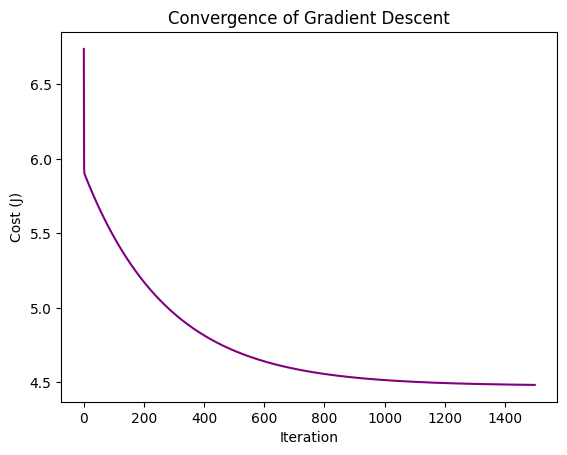

In [15]:
plt.plot(j_his, color="purple")
plt.xlabel("Iteration")
plt.ylabel("Cost (J)")
plt.title("Convergence of Gradient Descent")
plt.show()

In [ ]:
m = x_train.shape[0]

pred = w*x_train + b

Text(0.5, 0, 'Population of City in 10,000s')

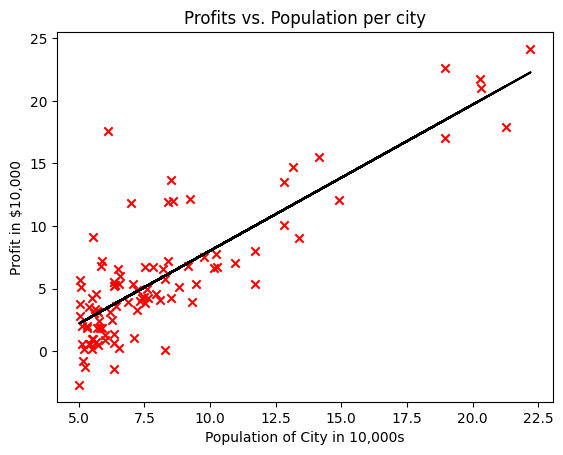

In [17]:
# Plot the linear fit
plt.plot(x_train, pred, c = "black")

# Create a scatter plot of the data.
plt.scatter(x_train, y_train, marker='x', c='r')

# Set the title
plt.title("Profits vs. Population per city")
# Set the y-axis label
plt.ylabel('Profit in $10,000')
# Set the x-axis label
plt.xlabel('Population of City in 10,000s')

In [18]:
predict1 = 3.5 * w + b
print('For population = 35,000, we predict a profit of $%.2f' % (predict1*10000))

predict2 = 7.0 * w + b
print('For population = 70,000, we predict a profit of $%.2f' % (predict2*10000))

For population = 35,000, we predict a profit of $4519.77
For population = 70,000, we predict a profit of $45342.45
